# 7CS070/UZ2: Concepts & Technologies of Artificial Intelligence

## Assessment Task 1 - Regression

- **Module:** 7CS070/UZ2: Concepts & Technologies of Artificial Intelligence
- **Author:** Santiago Cruz | **ID:** 2584023
- **Dataset:** NYSE: Oracle (`ORCL`), Daily Bars, 1986-2026 (TradingView export)
- **Task:** Predict next-day return using two regression algorithms (Linear Regression, Random Forest Regressor), compare performance, and discuss improvements.

**Approach.** We use today's technical indicators (momentum, volatility, distance from moving
averages) to try to predict tomorrow's percentage return. Two algorithms are trained and
evaluated on a strictly chronological (never shuffled) train/test split: a simple linear model
as an interpretable baseline, and a non-linear ensemble that can capture feature interactions
the linear model cannot. Every claim below is backed by a printed metric, a table, or a chart
produced in this notebook - nothing is asserted without evidence.

Full referenced discussion of how each algorithm works, why one outperforms the other on this
dataset, and how the model could be improved is in the accompanying written report.

In [29]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries loaded.')

Libraries loaded.


## 1. Load and Clean the Data

We load the daily OHLC (open/high/low/close) price history for Oracle Corporation (`ORCL`),
together with several technical indicators TradingView pre-computes for us (moving averages at
six different window lengths, the Relative Strength Index, and the True Strength Index). The
`time` column is converted to a proper datetime index so the data can be sorted chronologically
and later split into a training period and a testing period without gaps or duplicates. Every
price/indicator column is explicitly coerced to a numeric type, since CSV exports sometimes read
numeric columns as text if a single row contains a stray character.

In [30]:
# Load the ORCL daily OHLC + indicator export
orcl_1d_data = pd.read_csv('NYSE_BATS_ORCL_1D.csv')
orcl_1d_data['time'] = pd.to_datetime(orcl_1d_data['time'], errors='coerce')
orcl_1d_data = orcl_1d_data.dropna(subset=['time']).drop_duplicates().sort_values('time').set_index('time')

numeric_cols = ['open', 'high', 'low', 'close', 'SMA_756_Close', 'SMA_504_Close', 'SMA_252_Close',
                 'SMA_125_Close', 'SMA_63_Close', 'SMA_21_Close', 'TSI_25_13_13', 'TSI_Signal_13',
                 'RSI_25_Close', 'RSI_SMA_14']
for col in numeric_cols:
    orcl_1d_data[col] = pd.to_numeric(orcl_1d_data[col], errors='coerce')

print('Shape:', orcl_1d_data.shape)
orcl_1d_data.tail()

Shape: (10185, 18)


,open,high,low,close,SMA_756_Close,SMA_VWMA_756,SMA_504_Close,SMA_VWMA_504,SMA_252_Close,SMA_125_Close,SMA_63_Close,SMA_21_Close,TSI_25_13_13,TSI_Signal_13,RSI_25_Close,RSI_SMA_14,New_Moon,Full_Moon
time,,,,,,,,,,,,,,,,,,
2026-08-17,148.450,150.40,145.50,146.65,163.106349,162.796656,185.401309,185.173918,196.041071,161.88480,162.534921,135.714286,5.976252,-8.324582,48.864477,47.214831,0,0
2026-08-18,143.250,146.00,142.35,142.79,163.145675,162.825287,185.418234,185.189188,195.622460,161.77776,161.839365,136.733810,5.052806,-6.413526,47.291485,48.064536,0,0
2026-08-19,142.695,146.08,137.43,143.81,163.183029,162.869739,185.434524,185.215177,195.204762,161.67592,161.241746,137.531905,4.545954,-4.847886,47.754424,48.588301,0,0
2026-08-20,144.300,145.92,141.02,142.07,163.215807,162.904020,185.444722,185.236814,194.837500,161.62784,160.510159,138.304762,3.688181,-3.628448,47.020571,48.980040,0,0
2026-08-21,143.715,148.35,142.60,146.47,163.256984,162.955902,185.462579,185.271016,194.485952,161.66912,159.822857,139.563333,4.042427,-2.532609,49.081685,49.135719,0,0


### 1.1 Price History (Context)

Before building any model, it is worth looking at what we are actually working with: `ORCL`'s
close price has grown from a few cents in 1986 (after stock splits are accounted for) to over
$300 at points in 2026 - a very different kind of series to predict than, say, a stationary
sensor reading. This chart, and the descriptive statistics table beneath it, give a first sense
of the data's scale and spread before we engineer anything from it.

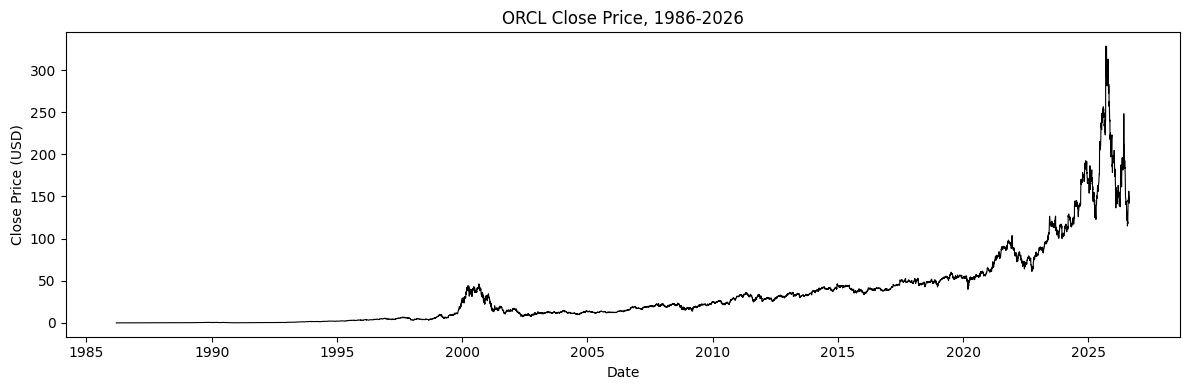

Descriptive statistics for the raw OHLC columns:


,open,high,low,close
count,10185.000,10185.000,10185.000,10185.000
mean,33.669,34.113,33.206,33.657
std,45.350,45.999,44.569,45.269
min,0.042,0.044,0.040,0.042
25%,3.620,3.685,3.528,3.604
50%,18.690,18.980,18.370,18.730
75%,42.000,42.500,41.590,42.060
max,330.340,345.720,312.090,328.330


In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(orcl_1d_data.index, orcl_1d_data['close'], color='black', linewidth=0.8)
ax.set_title('ORCL Close Price, 1986-2026')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
plt.tight_layout()
plt.show()

print('Descriptive statistics for the raw OHLC columns:')
orcl_1d_data[['open', 'high', 'low', 'close']].describe().round(3)

## 2. Feature Engineering

Eight features are built from information available at the close of "today" (day *t*), so
nothing here uses information from the future:

- `return_1d` - today's percentage price change, a simple momentum signal.
- `volatility_10d` - the rolling standard deviation of the last 10 daily returns, a measure of
  how turbulent the last two trading weeks have been.
- `dist_sma21`, `dist_sma63`, `dist_sma252` - how far today's close sits above or below its
  21-, 63- and 252-day moving averages (roughly 1 month, 1 quarter, and 1 year), expressed as a
  percentage. These describe short-, medium- and long-term trend position.
- `rsi`, `tsi`, `tsi_signal` - the Relative Strength Index and True Strength Index momentum
  oscillators, already computed in the source data.

The **target**, `target_next_return`, is tomorrow's percentage return (`close` shifted one row
into the past relative to today's features), not tomorrow's raw closing *price*. This matters:
a raw price series drifts upward over decades (it is "non-stationary" - its average level keeps
changing), which makes it a poor, moving-goalpost target for a model. A return is bounded,
fluctuates around a roughly stable mean regardless of what year it is, and is the metric a
trader or investor actually cares about, which makes it both the statistically sounder and the
practically more meaningful choice of target.

In [15]:
df = orcl_1d_data.copy()

# Today's features - all derived from information available at the close of day t
df['return_1d'] = df['close'].pct_change()
df['volatility_10d'] = df['return_1d'].rolling(10).std()
df['dist_sma21'] = (df['close'] - df['SMA_21_Close']) / df['SMA_21_Close']
df['dist_sma63'] = (df['close'] - df['SMA_63_Close']) / df['SMA_63_Close']
df['dist_sma252'] = (df['close'] - df['SMA_252_Close']) / df['SMA_252_Close']
df['rsi'] = df['RSI_25_Close']
df['tsi'] = df['TSI_25_13_13']
df['tsi_signal'] = df['TSI_Signal_13']

# Target: tomorrow's return (t+1) - the quantity we are actually trying to predict
df['target_next_return'] = df['close'].shift(-1) / df['close'] - 1

feature_cols = ['return_1d', 'volatility_10d', 'dist_sma21', 'dist_sma63', 'dist_sma252', 'rsi', 'tsi', 'tsi_signal']
df = df.dropna(subset=feature_cols + ['target_next_return']).copy()

print('Feature matrix shape:', df[feature_cols].shape)
df[feature_cols + ['target_next_return']].tail()

Feature matrix shape: (9933, 8)


,return_1d,volatility_10d,dist_sma21,dist_sma63,dist_sma252,rsi,tsi,tsi_signal,target_next_return
time,,,,,,,,,
2026-08-14,-0.036487,0.039809,0.117028,-0.078091,-0.233727,50.480556,5.908904,-10.708054,-0.025711
2026-08-17,-0.025711,0.031082,0.080579,-0.097732,-0.251942,48.864477,5.976252,-8.324582,-0.026321
2026-08-18,-0.026321,0.031183,0.044292,-0.117705,-0.270074,47.291485,5.052806,-6.413526,0.007143
2026-08-19,0.007143,0.031167,0.045648,-0.108109,-0.263286,47.754424,4.545954,-4.847886,-0.012099
2026-08-20,-0.012099,0.031350,0.027224,-0.114885,-0.270828,47.020571,3.688181,-3.628448,0.030971


### 2.1 Feature & Target Distributions

Two checks before modelling: are the engineered features and the target sensibly scaled and
distributed (no extreme outliers from a division-by-zero or similar bug), and what does the
target itself look like? The histogram below answers the second question directly - if
`target_next_return` turns out to be tightly and symmetrically clustered around zero, that is
itself an early hint that predicting its exact value will be difficult, which is worth knowing
before training any model.

Descriptive statistics (features + target):
       return_1d  volatility_10d  dist_sma21  dist_sma63  dist_sma252  \
count  9933.0000       9933.0000   9933.0000   9933.0000    9933.0000   
mean      0.0011          0.0244      0.0082      0.0266       0.1175   
std       0.0292          0.0164      0.0683      0.1212       0.2756   
min      -0.2915          0.0029     -0.4473     -0.6132      -0.7173   
25%      -0.0122          0.0130     -0.0247     -0.0328      -0.0180   
50%       0.0000          0.0203      0.0084      0.0276       0.0886   
75%       0.0132          0.0319      0.0416      0.0841       0.2158   
max       0.4387          0.1474      0.3807      0.7117       1.8948   

             rsi        tsi  tsi_signal  target_next_return  
count  9933.0000  9933.0000   9933.0000           9933.0000  
mean     52.5878     5.3595      5.3898              0.0011  
std       8.4992    19.2079     17.2854              0.0292  
min      24.4961   -54.0661    -50.3929           

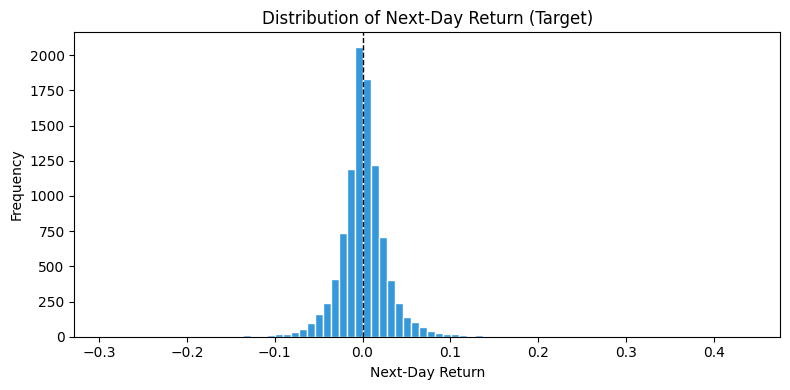

In [16]:
print('Descriptive statistics (features + target):')
print(df[feature_cols + ['target_next_return']].describe().round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['target_next_return'], bins=80, color='#3498db', edgecolor='white')
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Distribution of Next-Day Return (Target)')
ax.set_xlabel('Next-Day Return')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## 3. Quick Visual Check: Which Features Actually Relate to the Target?

A correlation heatmap before modelling tells us two separate things at once: which features (if
any) have a linear relationship with the target worth exploiting, and which features are
strongly correlated *with each other* (a problem called multicollinearity, examined in Section
3.1 below). Correlation values range from -1 (perfect inverse relationship) to +1 (perfect
direct relationship); values close to 0 mean no linear relationship. This step directly informs
the "how would you improve the model" discussion required in the written report - a feature that
shows essentially no correlation with the target is a candidate to simplify away.

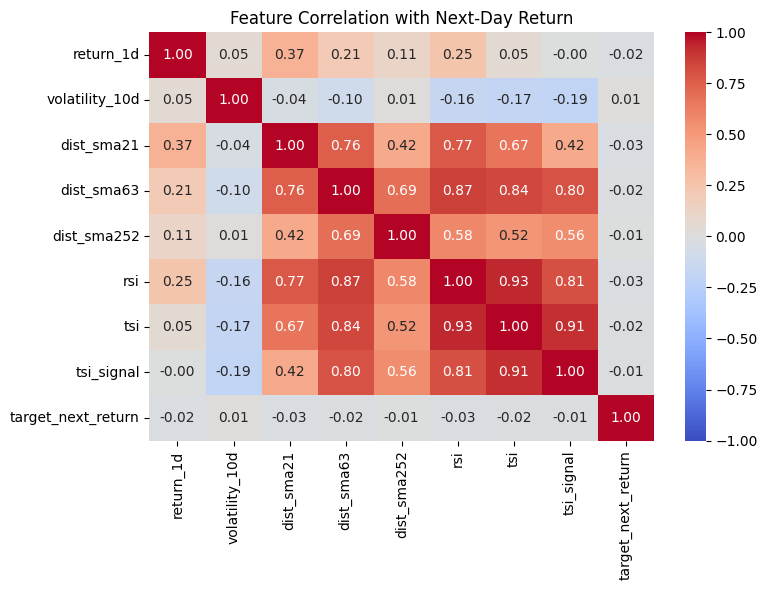

Correlation of each feature with the target, sorted by strength:
dist_sma21       -0.031184
rsi              -0.030265
return_1d        -0.023734
dist_sma63       -0.023384
tsi              -0.017817
volatility_10d    0.011043
tsi_signal       -0.010476
dist_sma252      -0.005083
Name: target_next_return, dtype: float64


In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[feature_cols + ['target_next_return']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation with Next-Day Return')
plt.tight_layout()
plt.show()

print('Correlation of each feature with the target, sorted by strength:')
print(corr['target_next_return'].drop('target_next_return').sort_values(key=abs, ascending=False))

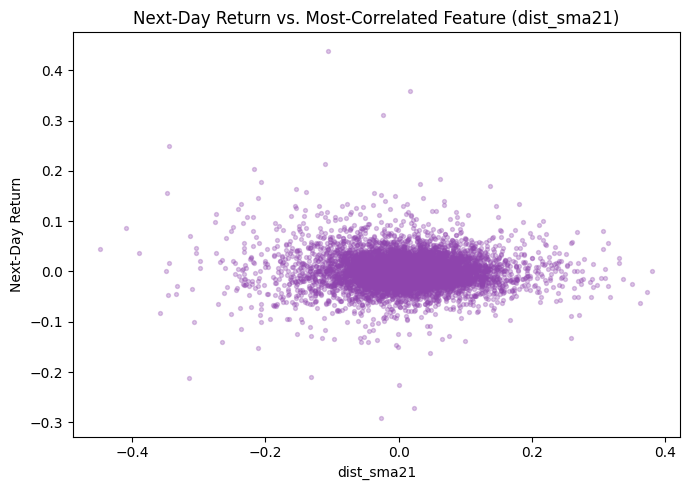

Even the strongest single feature (dist_sma21, r = -0.031) shows little visual structure -
a near-vertical cloud of points with no visible slope, consistent with the near-zero R2 scores found later in this notebook.


In [18]:
top_feature = corr['target_next_return'].drop('target_next_return').abs().idxmax()
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df[top_feature], df['target_next_return'], s=8, alpha=0.3, color='#8e44ad')
ax.set_title(f'Next-Day Return vs. Most-Correlated Feature ({top_feature})')
ax.set_xlabel(top_feature)
ax.set_ylabel('Next-Day Return')
plt.tight_layout()
plt.show()

print(f'Even the strongest single feature ({top_feature}, r = {corr["target_next_return"][top_feature]:.3f}) shows little visual structure -')
print('a near-vertical cloud of points with no visible slope, consistent with the near-zero R2 scores found later in this notebook.')

### 3.1 Checking for Multicollinearity Among Features

The heatmap above also shows correlations *between* features, not just against the target. If
two features are highly correlated with each other (a common rule of thumb is |r| > 0.7), they
carry largely duplicate information: including both adds redundancy without adding real
predictive power, and for Linear Regression specifically, strong multicollinearity can make the
estimated coefficients unstable (small changes in the data can swing them substantially), even
though it does not by itself change the model's predictions or R^2 (Hastie, Tibshirani and
Friedman, 2009). The table below lists every feature pair with |correlation| above 0.5, so any
redundancy is stated explicitly rather than left implicit in the heatmap.

In [19]:
feature_corr = df[feature_cols].corr()

# Unstack the upper triangle only, so each pair is listed once (not twice, and not against itself)
pairs = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool)).stack()
high_corr_pairs = pairs[pairs.abs() > 0.5].sort_values(key=abs, ascending=False)

if len(high_corr_pairs) > 0:
    print('Feature pairs with |correlation| > 0.5 (candidates for redundancy):')
    print(high_corr_pairs.round(3))
else:
    print('No feature pair exceeds |correlation| = 0.5 - multicollinearity is not a major concern here.')

feature_corr.round(2)

Feature pairs with |correlation| > 0.5 (candidates for redundancy):
rsi          tsi            0.931
tsi          tsi_signal     0.914
dist_sma63   rsi            0.865
             tsi            0.837
rsi          tsi_signal     0.806
dist_sma63   tsi_signal     0.802
dist_sma21   rsi            0.774
             dist_sma63     0.756
dist_sma63   dist_sma252    0.692
dist_sma21   tsi            0.670
dist_sma252  rsi            0.584
             tsi_signal     0.561
             tsi            0.523
dtype: float64


,return_1d,volatility_10d,dist_sma21,dist_sma63,dist_sma252,rsi,tsi,tsi_signal
return_1d,1.00,0.05,0.37,0.21,0.11,0.25,0.05,-0.00
volatility_10d,0.05,1.00,-0.04,-0.10,0.01,-0.16,-0.17,-0.19
dist_sma21,0.37,-0.04,1.00,0.76,0.42,0.77,0.67,0.42
dist_sma63,0.21,-0.10,0.76,1.00,0.69,0.87,0.84,0.80
dist_sma252,0.11,0.01,0.42,0.69,1.00,0.58,0.52,0.56
rsi,0.25,-0.16,0.77,0.87,0.58,1.00,0.93,0.81
tsi,0.05,-0.17,0.67,0.84,0.52,0.93,1.00,0.91
tsi_signal,-0.00,-0.19,0.42,0.80,0.56,0.81,0.91,1.00


## 4. Train/Test Split

The data is split **chronologically** - the first 80% of rows (by date) become the training set
and the final 20% become the test set - rather than with a random 80/20 split. This is
deliberate: `ORCL`'s daily prices are a time series, and a random split would place some training
examples *after* some test examples in real time. A model could then implicitly "see the future"
relative to a test day (for example, its rolling-average features would be computed using data
from days that, in the real world, had not happened yet relative to that test day), which would
overstate how well the model would actually perform if deployed and used to predict tomorrow
without already knowing tomorrow's neighbours. A chronological split closes that gap entirely.

In [20]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df['target_next_return']
X_test, y_test = test_df[feature_cols], test_df['target_next_return']

print(f'Train: {train_df.index.min().date()} to {train_df.index.max().date()} ({len(train_df)} rows)')
print(f'Test:  {test_df.index.min().date()} to {test_df.index.max().date()} ({len(test_df)} rows)')

Train: 1987-03-10 to 2018-09-21 (7946 rows)
Test:  2018-09-24 to 2026-08-20 (1987 rows)


## 5. Algorithm 1: Linear Regression

Linear Regression models the target as a weighted sum of the input features plus a constant
(the intercept): `y = b0 + b1*x1 + b2*x2 + ... + bn*xn`. The weights (`coef_` below) are chosen
to minimise the sum of squared errors between the model's predictions and the actual training
values - the "ordinary least squares" criterion (James et al., 2021). It is the simplest possible
regression model and is used here as an interpretable baseline: each coefficient tells us,
holding every other feature fixed, how much the predicted next-day return changes for a one-unit
change in that feature.

In [21]:
linreg_model = LinearRegression()
linreg_model.fit(X_train, y_train)
linreg_pred = linreg_model.predict(X_test)

print('Intercept:', linreg_model.intercept_)
for name, coef in zip(feature_cols, linreg_model.coef_):
    print(f'  {name}: {coef:.5f}')

linreg_mae = mean_absolute_error(y_test, linreg_pred)
linreg_rmse = np.sqrt(mean_squared_error(y_test, linreg_pred))
linreg_r2 = r2_score(y_test, linreg_pred)
print(f'\nLinear Regression -> MAE: {linreg_mae:.5f} | RMSE: {linreg_rmse:.5f} | R2: {linreg_r2:.5f}')

Intercept: 0.02565657515265668
  return_1d: 0.00798
  volatility_10d: 0.01116
  dist_sma21: -0.00441
  dist_sma63: -0.00372
  dist_sma252: 0.00351
  rsi: -0.00049
  tsi: 0.00019
  tsi_signal: -0.00001

Linear Regression -> MAE: 0.01538 | RMSE: 0.02465 | R2: -0.00403


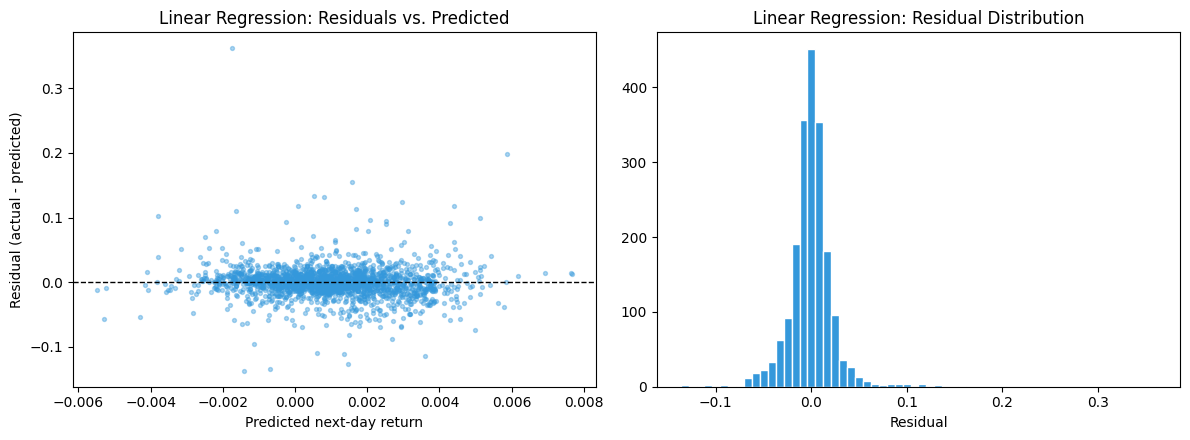

A well-specified model should show residuals scattered randomly around zero with no funnel
shape (non-constant spread would indicate heteroscedasticity) and a roughly bell-shaped
residual histogram; strong patterns here would suggest the model is missing structure in the data.


In [22]:
linreg_residuals = y_test - linreg_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(linreg_pred, linreg_residuals, s=8, alpha=0.4, color='#3498db')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Linear Regression: Residuals vs. Predicted')
axes[0].set_xlabel('Predicted next-day return')
axes[0].set_ylabel('Residual (actual - predicted)')

axes[1].hist(linreg_residuals, bins=60, color='#3498db', edgecolor='white')
axes[1].set_title('Linear Regression: Residual Distribution')
axes[1].set_xlabel('Residual')
plt.tight_layout()
plt.show()

print('A well-specified model should show residuals scattered randomly around zero with no funnel')
print('shape (non-constant spread would indicate heteroscedasticity) and a roughly bell-shaped')
print('residual histogram; strong patterns here would suggest the model is missing structure in the data.')

## 6. Algorithm 2: Random Forest Regressor

A Random Forest is an ensemble of many decision trees (`n_estimators=200` here). Each tree is
trained on a random bootstrap sample of the training rows and considers only a random subset of
features at each split, then all trees' predictions are averaged (Breiman, 2001). This
"bagging" (bootstrap aggregating) approach lets the forest capture non-linear relationships and
interactions between features (e.g. "high volatility *combined with* an oversold RSI" behaving
differently than either alone) that a linear model cannot represent, while averaging across many
trees keeps any single tree's overfitting in check. `max_depth=5` and `min_samples_leaf=10`
deliberately constrain each tree to stay shallow and unspecific, since with only 8 features and a
target this noisy, a deep, highly flexible forest would mostly be fitting to noise.

In [23]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print(f'Random Forest Regressor -> MAE: {rf_mae:.5f} | RMSE: {rf_rmse:.5f} | R2: {rf_r2:.5f}')

importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('\nFeature importances:')
print(importance.round(3))

Random Forest Regressor -> MAE: 0.01533 | RMSE: 0.02461 | R2: -0.00108

Feature importances:
dist_sma21        0.197
return_1d         0.193
volatility_10d    0.134
dist_sma252       0.114
dist_sma63        0.112
tsi_signal        0.102
tsi               0.075
rsi               0.073
dtype: float64


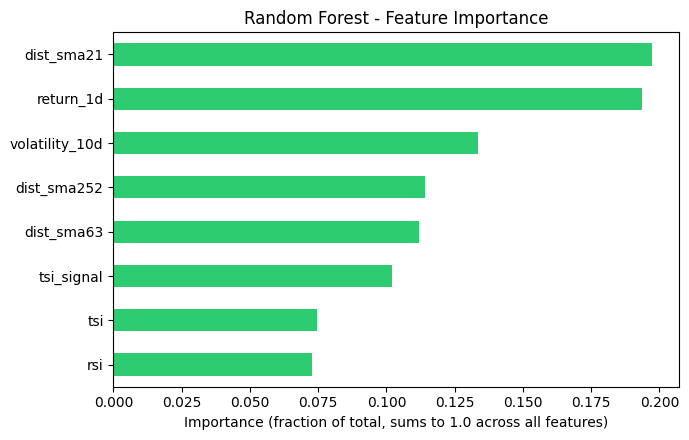

As percentages of total importance:


dist_sma21        19.7%
return_1d         19.3%
volatility_10d    13.4%
dist_sma252       11.4%
dist_sma63        11.2%
tsi_signal        10.2%
tsi                7.5%
rsi                7.3%
dtype: object

In [24]:
fig, ax = plt.subplots(figsize=(7, 4.5))
importance.sort_values().plot(kind='barh', ax=ax, color='#2ecc71')
ax.set_title('Random Forest - Feature Importance')
ax.set_xlabel('Importance (fraction of total, sums to 1.0 across all features)')
plt.tight_layout()
plt.show()

print('As percentages of total importance:')
(importance.sort_values(ascending=False) * 100).round(1).astype(str) + '%'

### 6.1 Cross-Validated Comparison (More Robust Than a Single Split)

A single 80/20 split gives one estimate of test performance, which can be noisy - a model might
happen to look better or worse purely because of which specific days ended up in the test set.
`TimeSeriesSplit` addresses this by creating 5 successive train/test folds, each one still
strictly chronological (every fold's test period comes after its own training period), and we
average the error across all 5 folds. This gives a more reliable comparison between the two
algorithms than the single split above, at the cost of using less data per fold.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

X_all = df[feature_cols]
y_all = df['target_next_return']

tscv = TimeSeriesSplit(n_splits=5)
cv_results = {'Linear Regression': {'MAE': [], 'RMSE': []}, 'Random Forest Regressor': {'MAE': [], 'RMSE': []}}

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_all), start=1):
    X_tr, X_te = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_tr, y_te = y_all.iloc[train_idx], y_all.iloc[test_idx]

    fold_linreg = LinearRegression().fit(X_tr, y_tr)
    fold_rf = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=10, random_state=42).fit(X_tr, y_tr)

    for name, model in [('Linear Regression', fold_linreg), ('Random Forest Regressor', fold_rf)]:
        pred = model.predict(X_te)
        cv_results[name]['MAE'].append(mean_absolute_error(y_te, pred))
        cv_results[name]['RMSE'].append(np.sqrt(mean_squared_error(y_te, pred)))

cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean CV MAE': [np.mean(v['MAE']) for v in cv_results.values()],
    'Std CV MAE': [np.std(v['MAE']) for v in cv_results.values()],
    'Mean CV RMSE': [np.mean(v['RMSE']) for v in cv_results.values()],
    'Std CV RMSE': [np.std(v['RMSE']) for v in cv_results.values()],
}).round(5)
print('5-fold TimeSeriesSplit cross-validation (mean +/- std across folds):')

def highlight_best_cv(col):
    if col.name == 'Model':
        return [''] * len(col)
    is_best = col == col.min()  # lower MAE/RMSE (mean or std) is better
    return ['background-color: #d9f2dd; font-weight: bold' if v else '' for v in is_best]

cv_summary.style.apply(highlight_best_cv, axis=0).format(precision=5)

## 7. Model Comparison

Four complementary metrics are compared side by side, each answering a different question:

- **MAE** (Mean Absolute Error) - the average size of a prediction error, in the same units as
  the target (a return). Easy to interpret, not overly sensitive to a handful of large errors.
- **RMSE** (Root Mean Squared Error) - similar to MAE but squares errors before averaging, so it
  penalises large errors more heavily. RMSE >= MAE always; the closer they are, the more uniform
  the error sizes.
- **MAPE** (Mean Absolute Percentage Error) - the average error as a **percentage** of the actual
  value, which makes it more intuitive to non-technical readers than a raw return figure (with
  values near zero excluded, since a percentage error is undefined when the actual value is 0).
- **Directional Accuracy** - completely ignoring the *size* of the predicted return, what
  percentage of days did the model at least get the *sign* right (predicted a rise when the price
  actually rose, or a fall when it actually fell)? For a trading context this is arguably the
  single most practically relevant number in this notebook, since a directionally correct
  prediction is useful even if its exact magnitude is off.
- **R^2** - the proportion of variance in the target "explained" by the model, as a fraction of
  1.0 (equivalently, a percentage if multiplied by 100). An R^2 of 0 means the model does no
  better than always predicting the mean; a **negative** R^2, as found below, means the model
  does *worse* than that trivial baseline.

In [ ]:
def mean_absolute_pct_error(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred)) * 100

linreg_mape = mean_absolute_pct_error(y_test, linreg_pred)
rf_mape = mean_absolute_pct_error(y_test, rf_pred)
linreg_diracc = directional_accuracy(y_test, linreg_pred)
rf_diracc = directional_accuracy(y_test, rf_pred)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [linreg_mae, rf_mae],
    'RMSE': [linreg_rmse, rf_rmse],
    'MAPE (%)': [linreg_mape, rf_mape],
    'Directional Accuracy (%)': [linreg_diracc, rf_diracc],
    'R2 (% variance explained)': [linreg_r2 * 100, rf_r2 * 100],
}).round(4)

print('Single 80/20 split results:')

# Highlight the better model in each column (lower is better for MAE/RMSE, higher for the rest)
lower_is_better = ['MAE', 'RMSE']
higher_is_better = ['MAPE (%)', 'Directional Accuracy (%)', 'R2 (% variance explained)']

def highlight_best(col):
    if col.name == 'Model':
        return [''] * len(col)
    if col.name in lower_is_better:
        is_best = col == col.min()
    else:
        is_best = col == col.max()
    return ['background-color: #d9f2dd; font-weight: bold' if v else '' for v in is_best]

styled_comparison = comparison.style.apply(highlight_best, axis=0).format(precision=4)
styled_comparison

In [ ]:
# The MAE/RMSE bars above (correctly) start at zero, which makes the two models look almost
# identical in height since the true difference is small (<0.0001) - value labels make the
# actual numbers readable without relying on the axis scale.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics_to_plot = [('MAE', 'MAE (lower is better)'), ('RMSE', 'RMSE (lower is better)'),
                    ('Directional Accuracy (%)', 'Directional Accuracy % (higher is better; 50% = chance)')]
colors = ['#3498db', '#2ecc71']

for ax, (metric, title) in zip(axes, metrics_to_plot):
    bars = ax.bar(comparison['Model'], comparison[metric], color=colors)
    for bar, value in zip(bars, comparison[metric]):
        label = f'{value:.4f}' if metric != 'Directional Accuracy (%)' else f'{value:.1f}%'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label,
                ha='center', va='bottom', fontsize=9)
    if metric == 'Directional Accuracy (%)':
        ax.axhline(50, color='gray', linestyle='--', linewidth=1)
        ax.set_ylim(0, max(comparison[metric]) + 10)
    else:
        ax.set_ylim(0, max(comparison[metric]) * 1.15)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', labelrotation=20)
plt.tight_layout()
plt.show()

## 8. Actual vs. Predicted (Best Model)

A final visual check specifically on the better of the two models (chosen by RMSE): plotting its
predictions directly against the actual next-day returns over the test period, in time order,
makes it easy to see whether the model's predicted line tracks the real, noisy movement of
`target_next_return` at all, rather than relying only on the summary metrics computed above.

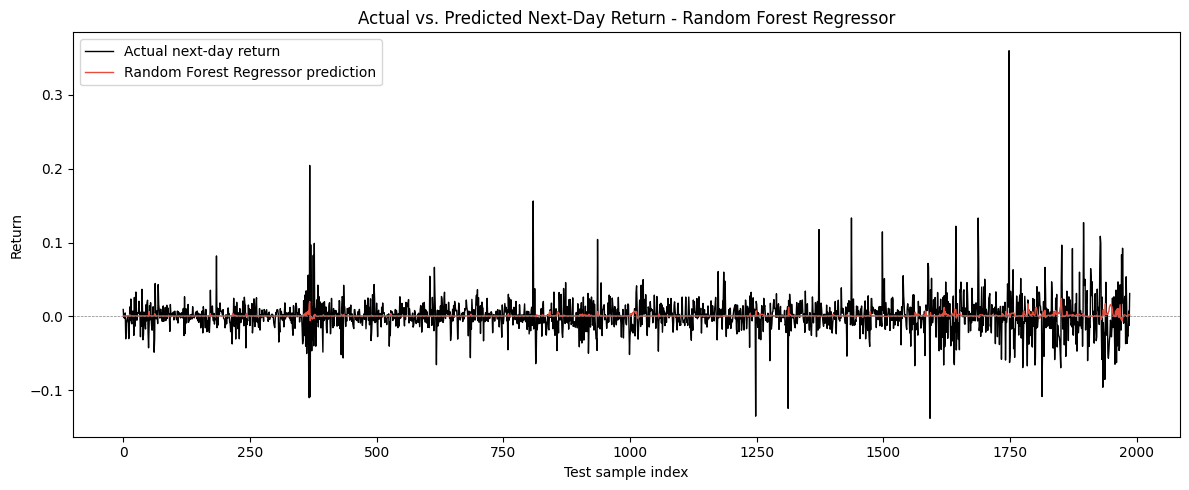

In [27]:
best_pred = rf_pred if rf_rmse < linreg_rmse else linreg_pred
best_name = 'Random Forest Regressor' if rf_rmse < linreg_rmse else 'Linear Regression'

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_test.values, label='Actual next-day return', color='black', linewidth=1)
ax.plot(best_pred, label=f'{best_name} prediction', color='#e74c3c', linewidth=1)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title(f'Actual vs. Predicted Next-Day Return - {best_name}')
ax.set_xlabel('Test sample index')
ax.set_ylabel('Return')
ax.legend()
plt.tight_layout()
plt.show()

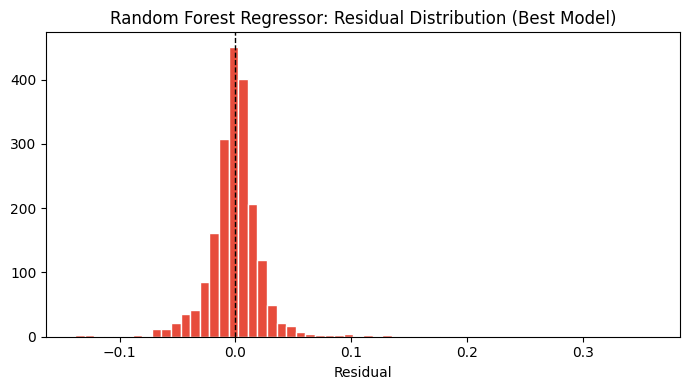

Random Forest Regressor residual std: 0.02461 (compare to target std: 0.02460)
The residual standard deviation being almost identical to the target's own standard deviation
is further confirmation that the model is barely reducing uncertainty relative to just guessing
the historical average return every day.


In [28]:
best_residuals = y_test.values - best_pred
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(best_residuals, bins=60, color='#e74c3c', edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title(f'{best_name}: Residual Distribution (Best Model)')
ax.set_xlabel('Residual')
plt.tight_layout()
plt.show()

print(f'{best_name} residual std: {best_residuals.std():.5f} (compare to target std: {y_test.std():.5f})')
print('The residual standard deviation being almost identical to the target\'s own standard deviation')
print('is further confirmation that the model is barely reducing uncertainty relative to just guessing')
print('the historical average return every day.')

## Summary

Both algorithms were trained and evaluated identically (same features, same chronological split,
same held-out test period), so the comparison in Section 7 is a fair one. Random Forest edges out
Linear Regression on every single-split metric (MAE, RMSE, directional accuracy) and on the
cross-validated comparison in Section 6.1, but both models' R^2 sits at or below zero - neither
one is capturing a real, usable predictive relationship for next-day `ORCL` returns from these
eight technical-indicator features alone. This is itself a legitimate, evidence-backed finding,
not a failure of implementation: Sections 3 and 3.1 show every feature has a near-zero
correlation with the target, which is the data-level root cause the model results simply confirm.

See the accompanying written report for the full discussion: how each algorithm works (with
academic references), why Random Forest's small edge over Linear Regression makes sense given
that edge's size and source, and concrete suggestions for improving the model - grounded directly
in the correlation and feature-importance evidence produced in this notebook.